# [NLP] EXERCISE 2
Model for 1997 names

In [ ]:
from google.colab import files

uploaded = files.upload()  # uploading .txt files

Saving noms_nadons_1997.txt to noms_nadons_1997.txt


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
nomsnadons1997 = 'noms_nadons_1997.txt'

with open(nomsnadons1997, 'r', encoding='utf-8') as f:
    nomsnadons1997 = f.read().splitlines()

print("Exemples de noms de nadons de 1997:", nomsnadons1997[:5])

Exemples de noms de nadons de 1997: ['marc', 'laura', 'maria', 'maría', 'david']


In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(nomsnadons1997))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: '-', 2: 'a', 3: 'b', 4: 'c', 5: 'd', 6: 'e', 7: 'f', 8: 'g', 9: 'h', 10: 'i', 11: 'j', 12: 'k', 13: 'l', 14: 'm', 15: 'n', 16: 'o', 17: 'p', 18: 'q', 19: 'r', 20: 's', 21: 't', 22: 'u', 23: 'v', 24: 'w', 25: 'x', 26: 'y', 27: 'z', 28: '·', 29: 'à', 30: 'á', 31: 'ç', 32: 'è', 33: 'é', 34: 'í', 35: 'ï', 36: 'ñ', 37: 'ò', 38: 'ó', 39: 'ú', 40: 'ü', 0: '.'}


In [ ]:
len(itos)

41

In [ ]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(nomsnadons1997)
n1 = int(0.8*len(nomsnadons1997))
n2 = int(0.9*len(nomsnadons1997))

Xtr, Ytr = build_dataset(nomsnadons1997[:n1])
Xdev, Ydev = build_dataset(nomsnadons1997[n1:n2])
Xte, Yte = build_dataset(nomsnadons1997[n2:])

torch.Size([5638, 3]) torch.Size([5638])
torch.Size([727, 3]) torch.Size([727])
torch.Size([725, 3]) torch.Size([725])


In [ ]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((41, 10), generator=g) # 10 dimensions for each character, you can change this, it's the space of the embedding
W1 = torch.randn((30, 200), generator=g) # 3 characters of 10 dimensions each, concatenated. 200dimensions is the output
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 41), generator=g)
b2 = torch.randn(41, generator=g)
parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters) # number of parameters in total

14851

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [ ]:
lri = []
lossi = []
stepi = []

In [ ]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

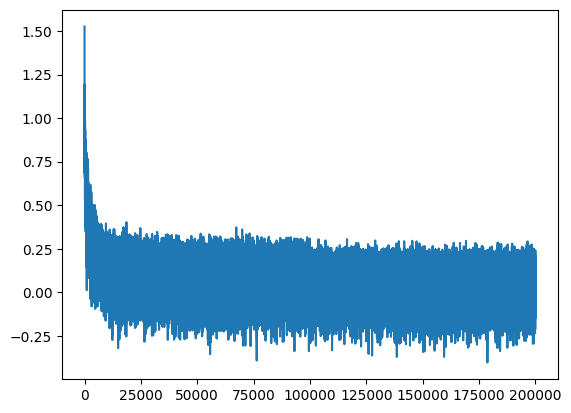

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
# training loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.1240, grad_fn=<NllLossBackward0>)

In [ ]:
# validation loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(4.0187, grad_fn=<NllLossBackward0>)

In [ ]:
# test loss
emb = C[Xte]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(4.1400, grad_fn=<NllLossBackward0>)

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(100):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

blancesc-josé.
paúl.
maria-ángeles.
saül.
adeu.
uriel.
lia.
mata.
joaniel.
estel.
andra.
oralina.
samadel-carles.
victor.
marçal.
zaid.
edgard.
jènifer.
maria.
adel-àngelenia.
conrad.
joannabigaïl.
hamza.
enric.
alexis.
aïd.
aityçitfna.
elina.
bert.
josé-davida.
mau.
blanit.
esperalt.
ahmed.
josé-maría.
elia.
nica.
iristhian.
carme.
vid.
bel.
andrea.
ald.
dolfonso.
oussef.
moha.
nabilal.
ilías.
josé-ramon.
asi.
eva.
àyoussamaría-ángelena.
kennís.
iván.
joan-miguer.
chaime.
cata.
nais.
áyounir.
llucasantia.
eudalima.
yoelina.
mussef.
yeraya.
artur.
janina.
naomi.
borionatàlia.
víctor-manuel.
víctor.
alia.
tatiffaniela.
jordán.
àgatal.
ignaci.
joan-luisa.
helesís--áigailar.
anio-davier.
àngelena.
cecilia.
josé-josé-manda.
alfons.
palo.
romàs.
josé-luis.
chaimon.
mau.
roberto.
nil.
hellem.
eugènia.
lías.
paula-marian.
bert.
maria-elena.
eva-maria.
carnacio.
salia.
sam.
andy.
